## Fraud Detection - EDA
Caishen Bank - Initial exploratory analysis of synthetic transaction data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/fraud_transactions.csv")
print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

### Class Balance
- isFraud: 6,354,407 legitimate (99.87%) vs 8,213 fraud (0.13%)
- Severe class imbalance — a model predicting "never fraud" would be 99.87% accurate but useless
- Need to prioritize recall/precision/F1 over raw accuracy

In [3]:
df.groupby('type')['isFraud'].agg(['count', 'sum'])

,count,sum
type,,
CASH_IN,1399284,0
CASH_OUT,2237500,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,532909,4097


In [4]:
df.groupby('type')['isFraud'].agg(['count', 'sum']).assign(
    fraud_rate_pct=lambda x: (x['sum'] / x['count'] * 100).round(3)
)

,count,sum,fraud_rate_pct
type,,,
CASH_IN,1399284,0,0.000
CASH_OUT,2237500,4116,0.184
DEBIT,41432,0,0.000
PAYMENT,2151495,0,0.000
TRANSFER,532909,4097,0.769


### Fraud by Transaction Type
- Fraud ONLY occurs in TRANSFER (4,097) and CASH_OUT (4,116)
- CASH_IN, DEBIT, PAYMENT: zero fraud cases
- Fraud rate within TRANSFER: ~0.769%, within CASH_OUT: ~0.184% fraud rate
- Strong signal: `type` is highly predictive — could filter to just these 2 types, or ensure model heavily weights this feature

In [6]:
pd.crosstab(df['isFlaggedFraud'], df['isFraud'])

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


### Naive Baseline (isFlaggedFraud)
- Only catches 16 of 8,213 fraud cases (0.2% recall)
- Confirms simple amount threshold is a poor fraud detector — our ML model needs to beat this baseline
- isFlaggedFraud itself should likely be dropped as a feature (it's a naive predictor, not a real signal, and including it might leak/confuse the model)

In [7]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


### Amount by Fraud Status
- Fraud mean: ~$1.47M vs legit mean: ~$178K
- Fraud median: ~$441K vs legit median: ~$74.7K
- Fraud transactions are typically much larger — `amount` is a useful predictive feature

In [ ]:

df[df['isFraud']==1][['oldbalanceOrg','newbalanceOrig']].describe()

,oldbalanceOrg,newbalanceOrig
count,8.213000e+03,8.213000e+03
mean,1.649668e+06,1.923926e+05
std,3.547719e+06,1.965666e+06
min,0.000000e+00,0.000000e+00
25%,1.258224e+05,0.000000e+00
50%,4.389835e+05,0.000000e+00
75%,1.517771e+06,0.000000e+00
max,5.958504e+07,4.958504e+07


### Balance Draining Pattern
- Fraud: median newbalanceOrig = $0 (account emptied)
- Fraud: median oldbalanceOrg = ~$439K before drain
- Strong signal: fraud transactions tend to zero out the origin account
- Could engineer a feature: balance_diff = oldbalanceOrg - newbalanceOrig, or a flag for "account fully drained"

In [ ]:
# Check for missing values across all columns
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

### Missing Values
- No nulls in any column — dataset is complete

### Multivariate Analysis: Correlation Among Predictors

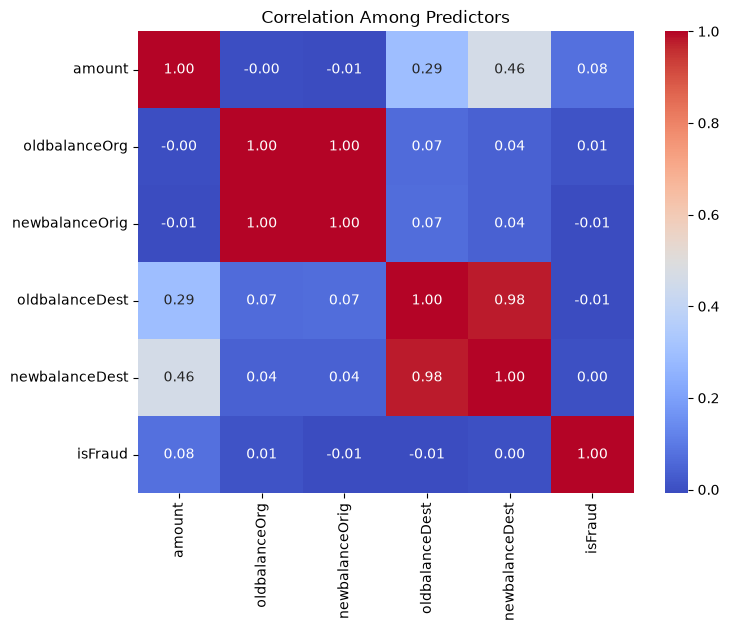

In [11]:
# Correlation heatmap among numeric predictors (not just vs isFraud)
import seaborn as sns

numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Among Predictors')
plt.show()

### Multivariate Findings
- `oldbalanceOrg` & `newbalanceOrig`: perfectly correlated (1.00) — redundant pair
- `oldbalanceDest` & `newbalanceDest`: highly correlated (0.98) — redundant pair
- Individually, raw balance columns show near-zero correlation with `isFraud`
- This explains why engineering `balance_diff_orig` (the difference) was necessary — the raw values alone don't separate fraud from legit, but the *drop pattern* does